In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from timm import create_model
from pathlib import Path
from model.image_dataset import ImageDataset
from model.classification import ClassificationType
from tqdm import tqdm
import timm
import numpy as np

# config

In [2]:
BATCH_SIZE = 64
EPOCHS = 20
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
data_dir = os.path.join(parent_dir, "data", "processed")

cuda:0


# Split 2

In [3]:
mean = [0.5099310278892517, 0.4330956041812897, 0.3907594382762909]
std = [0.4104351758956909, 0.4893591821193695, 0.4897149622440338]
train_transform  = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    ),
])

train_path = Path(os.path.join(data_dir, "train"))
val_path = Path(os.path.join(data_dir, "val"))
test_path = Path(os.path.join(data_dir, "test"))

train_dataset = ImageDataset(train_path, train_transform)
val_dataset = ImageDataset(val_path, eval_transform)
test_dataset = ImageDataset(test_path, eval_transform)

from torch.utils.data import Subset
# train_dataset = Subset(ImageDataset(train_path, transform), range(50000))
# val_dataset = Subset(ImageDataset(val_path, transform), range(1000))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


# load model

In [4]:
num_classes = ClassificationType.get_number_of_types()

# Tworzenie nieprzetrenowanego modelu ResNet
model = timm.create_model('resnet50', pretrained=False)

# Zamiana ostatniej warstwy klasyfikacyjnej
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# Reszta bez zmian
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_path = "MODEL2.pth"

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    avg_val_loss = val_running_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)

Epoch 1/20:  27%|██▋       | 748/2745 [01:11<03:13, 10.30it/s]C:\Users\kubas\anaconda3\envs\deeplearning\Lib\site-packages\PIL\Image.py:981: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluation: 100%|██████████| 386/386 [00:30<00:00, 12.74it/s]


Epoch 1/20, Train Loss: 0.2454, Val Loss: 0.1392


Evaluation: 100%|██████████| 386/386 [00:29<00:00, 12.96it/s]


Epoch 2/20, Train Loss: 0.1589, Val Loss: 0.1172


Evaluation: 100%|██████████| 386/386 [00:29<00:00, 12.93it/s]


...

Epoch 18/20, Train Loss: 0.0723, Val Loss: 0.0887


Evaluation: 100%|██████████| 386/386 [00:52<00:00,  7.29it/s]


Epoch 19/20, Train Loss: 0.0695, Val Loss: 0.0802


Evaluation: 100%|██████████| 386/386 [00:52<00:00,  7.35it/s]

Epoch 20/20, Train Loss: 0.0683, Val Loss: 0.0829


# plot

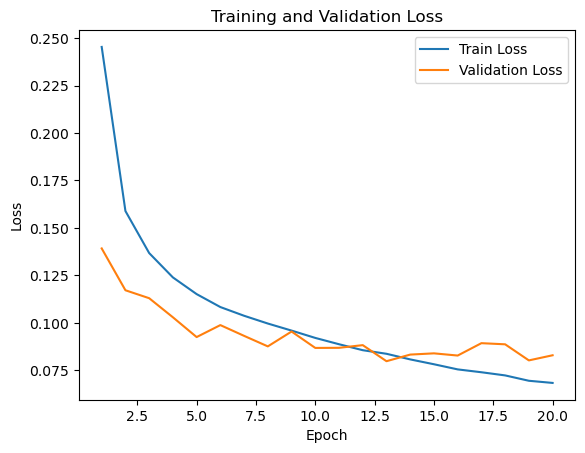

In [5]:
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()


In [6]:
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")

Testing: 100%|██████████| 346/346 [00:47<00:00,  7.27it/s]


✅ Test Accuracy: 97.33%


# Split 1

In [7]:
transform = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.ToTensor(),
])
train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))
val_path = Path(os.path.join(data_dir, "val"))

train_dataset = ImageDataset(train_path, transform)
test_dataset = ImageDataset(test_path, transform)
val_dataset = ImageDataset(val_path, transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = ClassificationType.get_number_of_types()

model = timm.create_model('resnet50', pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_path = "MODEL1.pth"

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    avg_val_loss = val_running_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)

Evaluation: 100%|██████████| 386/386 [00:49<00:00,  7.82it/s]


Epoch 1/20, Train Loss: 0.2089, Val Loss: 0.1348


Evaluation: 100%|██████████| 386/386 [00:49<00:00,  7.85it/s]


Epoch 2/20, Train Loss: 0.1291, Val Loss: 0.1145


Evaluation: 100%|██████████| 386/386 [00:50<00:00,  7.63it/s]


...

Epoch 18/20, Train Loss: 0.0177, Val Loss: 0.1521


Evaluation: 100%|██████████| 386/386 [00:49<00:00,  7.83it/s]


Epoch 19/20, Train Loss: 0.0169, Val Loss: 0.1679


Evaluation: 100%|██████████| 386/386 [00:49<00:00,  7.87it/s]

Epoch 20/20, Train Loss: 0.0163, Val Loss: 0.1542


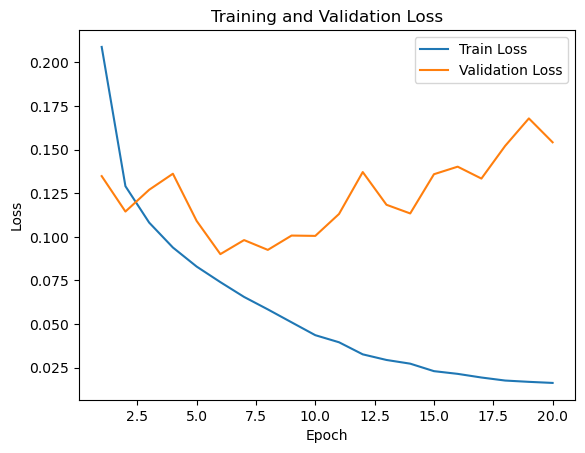

In [8]:
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()


In [9]:
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")

Testing: 100%|██████████| 346/346 [00:45<00:00,  7.63it/s]


✅ Test Accuracy: 97.02%


# Split 3

In [10]:
from torch.utils.data import Subset
mean = [0.5099310278892517, 0.4330956041812897, 0.3907594382762909]
std = [0.5104351758956909, 0.5893591821193695, 0.5897149622440338]
train_transform = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    ),
])

train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))

train_dataset = ImageDataset(train_path, train_transform)
test_dataset = ImageDataset(test_path, eval_transform)

val_size = int(0.2 * len(train_dataset))
train_indices = np.arange(len(train_dataset))
val_indices = np.random.choice(train_indices, size=val_size, replace=False)
val_dataset = Subset(train_dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


num_classes = ClassificationType.get_number_of_types()

model = timm.create_model('resnet50', pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_path = "MODEL3.pth"

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    avg_val_loss = val_running_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{EPOCHS}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)

Evaluation: 100%|██████████| 549/549 [01:20<00:00,  6.79it/s]


Epoch 1/20, Train Loss: 0.2492, Val Loss: 0.1647


Evaluation: 100%|██████████| 549/549 [01:22<00:00,  6.69it/s]


Epoch 2/20, Train Loss: 0.1587, Val Loss: 0.1415


Evaluation: 100%|██████████| 549/549 [01:22<00:00,  6.63it/s]


...

Epoch 18/20, Train Loss: 0.0732, Val Loss: 0.0622


Evaluation: 100%|██████████| 549/549 [01:21<00:00,  6.70it/s]


Epoch 19/20, Train Loss: 0.0715, Val Loss: 0.0606


Evaluation: 100%|██████████| 549/549 [01:23<00:00,  6.58it/s]

Epoch 20/20, Train Loss: 0.0689, Val Loss: 0.0608


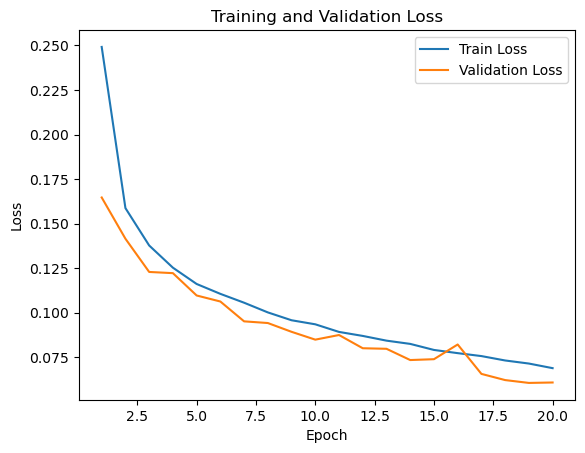

In [11]:
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

In [12]:
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")

Testing: 100%|██████████| 346/346 [00:48<00:00,  7.10it/s]


✅ Test Accuracy: 97.57%


# Overfit model

In [13]:
from torch.utils.data import Subset
transform = transforms.Compose([
    transforms.Resize(size=(32, 32)),
    transforms.ToTensor(),
])
train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))
val_path = Path(os.path.join(data_dir, "val"))

train_dataset = Subset(ImageDataset(train_path, transform), list(range(10000)))
test_dataset = ImageDataset(test_path, transform)
val_dataset = Subset(ImageDataset(val_path, transform), list(range(2000)))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

num_classes = ClassificationType.get_number_of_types()

model = timm.create_model('resnet50', pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

train_losses = []
val_losses = []
best_val_loss = float('inf')
# best_model_path = "overfit.pth"
overfit_epochs = 30

for epoch in range(overfit_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

    avg_val_loss = val_running_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{overfit_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        # torch.save(model.state_dict(), best_model_path)

Evaluation: 100%|██████████| 32/32 [00:03<00:00,  8.45it/s]


Epoch 1/30, Train Loss: 0.5693, Val Loss: 0.0214


Evaluation: 100%|██████████| 32/32 [00:03<00:00,  8.68it/s]


Epoch 2/30, Train Loss: 0.0337, Val Loss: 0.0283


Evaluation: 100%|██████████| 32/32 [00:03<00:00,  8.90it/s]


...

Epoch 28/30, Train Loss: 0.0080, Val Loss: 0.0163


Evaluation: 100%|██████████| 32/32 [00:03<00:00,  8.71it/s]


Epoch 29/30, Train Loss: 0.0118, Val Loss: 0.0131


Evaluation: 100%|██████████| 32/32 [00:03<00:00,  8.76it/s]

Epoch 30/30, Train Loss: 0.0091, Val Loss: 0.0498


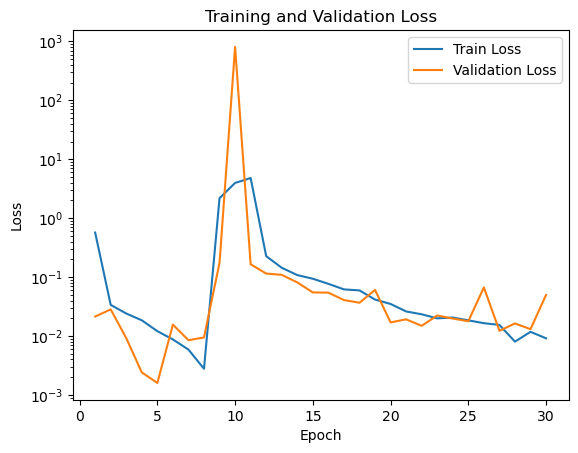

In [16]:
plt.plot(range(1, 30 + 1), train_losses, label="Train Loss")
plt.plot(range(1, 30 + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

In [15]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\n✅ Test Accuracy: {accuracy * 100:.2f}%")

Testing: 100%|██████████| 346/346 [00:46<00:00,  7.50it/s]


✅ Test Accuracy: 39.61%
